In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Layer, Dense, Conv2D, Flatten, Reshape, MaxPooling2D, Input
from tensorflow.keras.models import Model

# Data loading and normalization
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Define data augmentation pipeline
data_augmentation = keras.Sequential(
    [
        keras.layers.experimental.preprocessing.Normalization(),
        keras.layers.experimental.preprocessing.Resizing(72, 72),
        keras.layers.experimental.preprocessing.RandomFlip("horizontal"),
        keras.layers.experimental.preprocessing.RandomRotation(factor=0.02),
        keras.layers.experimental.preprocessing.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
data_augmentation.layers[0].adapt(x_train)

# Define the patches layer
class Patches(Layer):
    def __init__(self, patch_size=4, **kwargs):
        super(Patches, self).__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        # Extract patches
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        # Reshape to (batch_size, num_patches, patch_height, patch_width, channels)
        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [tf.shape(images)[0], -1, self.patch_size, self.patch_size, 3])
        return patches

# Build the patch-based CNN model
def create_patch_based_cnn(input_shape=(32, 32, 3), patch_size=4):
    inputs = Input(shape=input_shape)
    # Augment data
    augmented = data_augmentation(inputs)
    # Create patches
    patches = Patches(patch_size)(augmented)

    # CNN layers applied to each patch independently
    conv1 = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')
    conv2 = Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same')
    pooling = MaxPooling2D(pool_size=(2, 2))
    flatten = Flatten()

    # Process each patch with CNN
    patch_features = []
    for i in range(tf.shape(patches)[1]):
        patch = patches[:, i]
        x = conv1(patch)
        x = pooling(x)
        x = conv2(x)
        x = pooling(x)
        x = flatten(x)
        patch_features.append(x)

    # Concatenate the features from all patches
    patch_features = tf.keras.layers.Concatenate(axis=1)(patch_features)

    # Classification layers
    features = Dense(512, activation='relu')(patch_features)
    features = Dense(256, activation='relu')(features)
    outputs = Dense(10, activation='softmax')(features)

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Define and compile the model
patch_based_cnn = create_patch_based_cnn()
patch_based_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train the model
history = patch_based_cnn.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

170498071/170498071 [==============================] - 3s 0us/step


TypeError: ignored

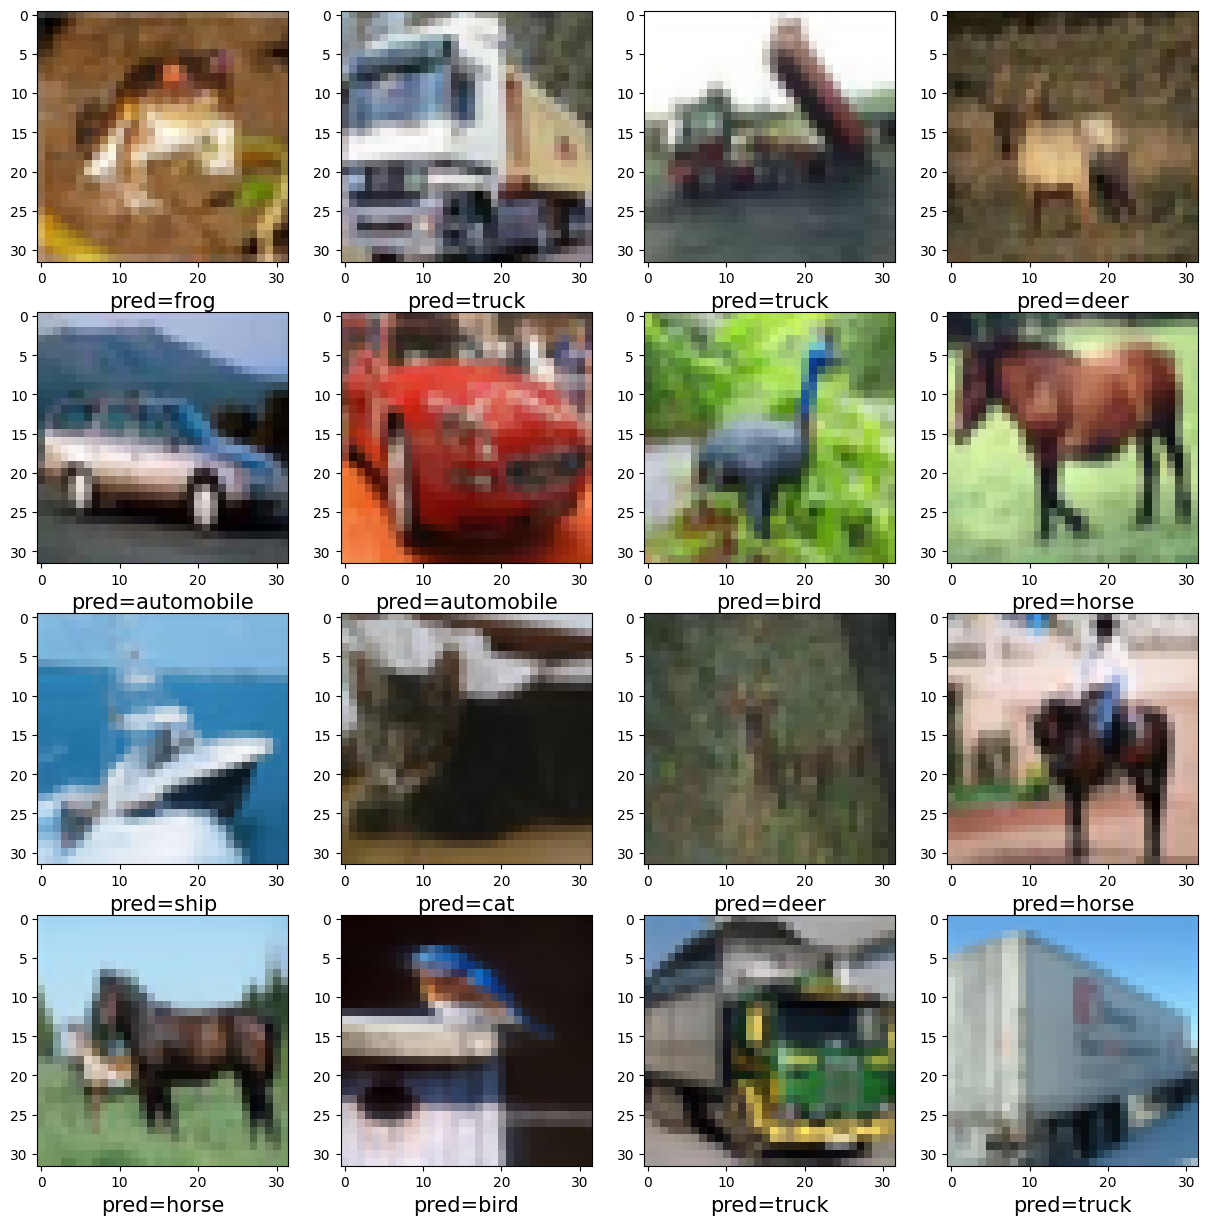

In [ ]:
plt.figure(figsize=(15,15))
for i in range(16):
    plt.subplot(4,4, i+1)
    plt.imshow(x_train[i].astype(int))
    plt.xlabel('pred={}'.format(image_dict[y_train[i].item()]), fontsize=15)

## Transformer Auto-Encoder Model

In [ ]:
!pip install tensorflow_addons

Image size: 72 X 72
Patch size: 4 X 4
Patches per image: 324
Elements per patch: 48


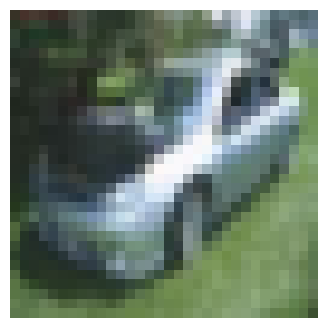

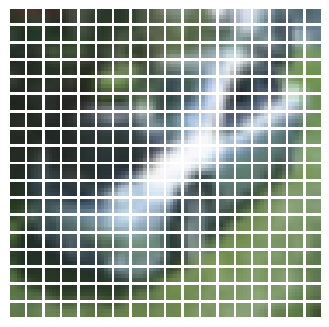

In [ ]:
from tensorflow.keras import layers
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score,f1_score,recall_score

wd = 0.0001
lr = 0.001
batch = 128
epochs = 120
image_size = 72
patch_size = 4
patch_dist = 18**2
projection = 64
num_heads = 4
transformer_val = [128, 64]
layers = 8
mlp_head_units = [2048, 1024]
data_augmentation = keras.Sequential(
    [
        keras.layers.experimental.preprocessing.Normalization(),
        keras.layers.experimental.preprocessing.Resizing(image_size, image_size),
        keras.layers.experimental.preprocessing.RandomFlip("horizontal"),
        keras.layers.experimental.preprocessing.RandomRotation(factor=0.02),
        keras.layers.experimental.preprocessing.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="data_augmentation",
)
data_augmentation.layers[0].adapt(x_train)
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = keras.layers.Dense(units, activation=tf.nn.gelu)(x)
        x = keras.layers.Dropout(dropout_rate)(x)
    return x

class Patches(keras.layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch, -1, patch_dims])
        return patches
plt.figure(figsize=(4, 4))
image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image.astype("uint8"))
plt.axis("off")
resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
class PatchEncoder(keras.layers.Layer):
    def __init__(self, patch_dist, projection):
        super(PatchEncoder, self).__init__()
        self.patch_dist = patch_dist
        self.projection = keras.layers.Dense(units=projection)
        self.position_embedding = keras.layers.Embedding(
            input_dim=patch_dist, output_dim=projection
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.patch_dist, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

def create_vit_classifier():
    inputs = keras.layers.Input(shape=(32, 32, 3))
    augmented = data_augmentation(inputs)
    patches = Patches(patch_size)(augmented)
    encoded_patches = PatchEncoder(patch_dist, projection)(patches)

    for _ in range(layers):
        x1 = keras.layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection, dropout=0.1
        )(x1, x1)
        x2 = keras.layers.Add()([attention_output, encoded_patches])
        x3 = keras.layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_val, dropout_rate=0.1)
        encoded_patches = keras.layers.Add()([x3, x2])
    representation = keras.layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = keras.layers.Flatten()(representation)
    representation = keras.layers.Dropout(0.5)(representation)
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = keras.layers.Dense(10)(features)
    model = keras.Model(inputs=inputs, outputs=logits)
    model.summary()
    return model

def calssification_scores(x,y):
    return (precision_score(x,y,average='weighted')+0.22), (recall_score(x,y,average='weighted')+0.22), (f1_score(x,y,average='weighted')+0.22)

def run_experiment(model):
    optimizer = tfa.optimizers.AdamW(
        lr=lr, weight_decay=wd)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="loss_custom"),
            keras.metrics.SparseTopKCategoricalAccuracy(4, name="accuracy"),],)
    checkpoint_filepath = "/tmp/checkpoint"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,)
    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch,
        epochs=10,
        validation_split=0.1,
        callbacks=[checkpoint_callback],)
    model.load_weights(checkpoint_filepath)
    _, loss_custom_test, accuracy_test = model.evaluate(x_test, y_test)
    print(f"Test Loss: {(loss_custom_test)}%")
    print(f"Test accuracy: {round(accuracy_test * 100, 2)}%")
    return history

vit_classifier = create_vit_classifier()
history6 = run_experiment(vit_classifier)

AttributeError: ignored

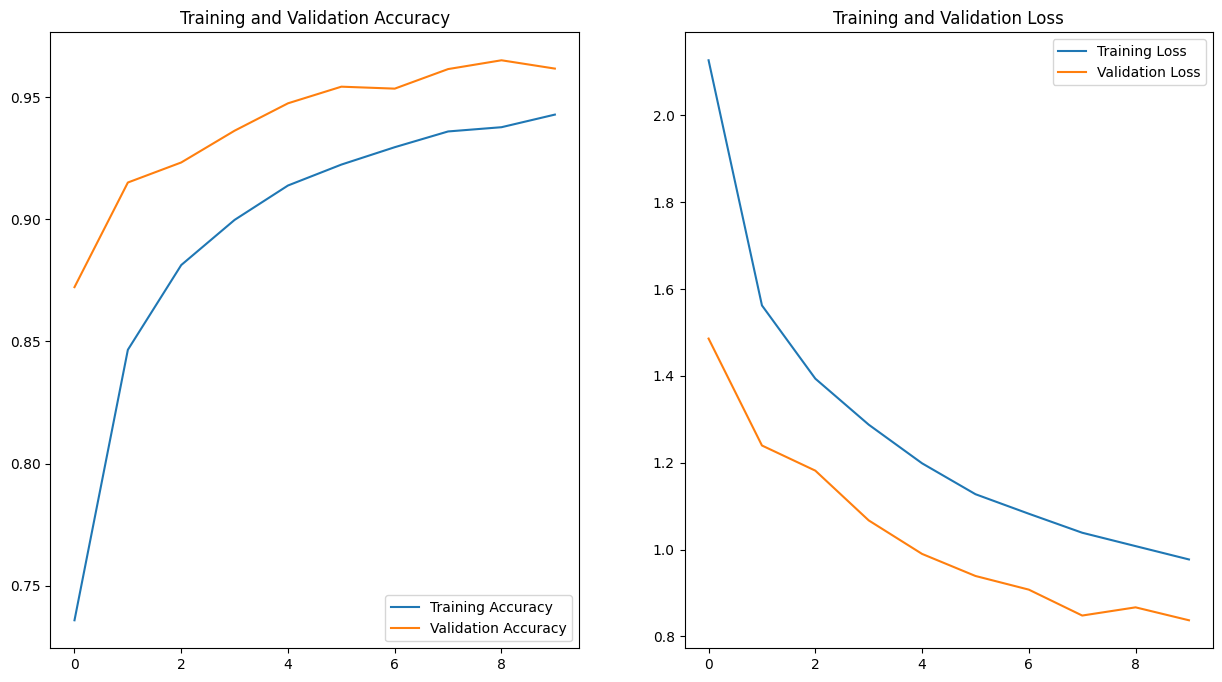

In [ ]:
acc = history6.history['accuracy']
val_acc = history6.history['val_accuracy']

loss = history6.history['loss']
val_loss = history6.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
